# 0. Imports

In [1]:
import random
import numpy as np
import torch
from torch import nn
import sklearn

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

seed_everything(42)

import torch
from torch.utils.data import DataLoader, TensorDataset

In [2]:
!nvidia-smi

Fri Sep 18 10:44:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:02:00.0 Off |                   On |
| N/A   36C    P0             60W /  400W |      45MiB /  95830MiB |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

# RNA-Binding Prediction with eCLIP Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgruano/elixir_AI4LS_rna_binding/blob/main/cnn_model.ipynb)

This notebook provides a starter template to fetch, inspect, and analyze the processed **eCLIP dataset** from Hugging Face ([`morrislab/eclip`](https://huggingface.co/datasets/morrislab/eclip), part of [mRNABench](https://github.com/morrislab/mRNABench)).

### Biological Question
Proteins and RNA do not act as independent biomolecules, but orchestrate cellular biology through protein-RNA interactions. Cross-linking experiments (such as eCLIP) followed by RNA sequencing detect transcriptome-wide binding events.

**Could training a machine learning model on this data be able to predict if a given protein binds to a given RNA molecule?**

## 1. Environment Setup & Dependencies

Install the Hugging Face `datasets` library, `pyarrow`, and `matplotlib` to read parquet-formatted biological datasets and create visualizations in Google Colab.

In [3]:
# Install required libraries in Colab
%pip install -q datasets pandas pyarrow matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Fetch Dataset from Hugging Face

The `morrislab/eclip` dataset contains eCLIP binding data across human cell lines:
- **`k562`**: Erythroleukemia cell line (~120+ RBPs)
- **`hepg2`**: Hepatocellular carcinoma cell line

We load the dataset using Hugging Face's `datasets` library.

In [4]:
from datasets import load_dataset
import pandas as pd

# Choose cell line configuration: 'k562' or 'hepg2'
CONFIG = "k562"

print(f"Fetching morrislab/eclip dataset (config: {CONFIG})...")
dataset = load_dataset("morrislab/eclip", CONFIG)
print("Dataset fetched successfully!\n")
print(dataset)

/home/dgarcia/miniforge3/envs/binding_cnn/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching morrislab/eclip dataset (config: k562)...


Dataset fetched successfully!

DatasetDict({
    train: Dataset({
        features: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice', 'target_AATF', 'target_ABCF1', 'target_AKAP1', 'target_APOBEC3C', 'target_AQR', 'target_BCCIP', 'target_BUD13', 'target_CDC40', 'target_CPEB4', 'target_CPSF6', 'target_CSTF2', 'target_CSTF2T', 'target_DDX21', 'target_DDX24', 'target_DDX3X', 'target_DDX42', 'target_DDX51', 'target_DDX52', 'target_DDX55', 'target_DDX6', 'target_DGCR8', 'target_DHX30', 'target_DKC1', 'target_DROSHA', 'target_EFTUD2', 'target_EIF3D', 'target_EIF3G', 'target_EIF3H', 'target_EIF4G2', 'target_EWSR1', 'target_EXOSC5', 'target_FAM120A', 'target_FASTKD2', 'target_FKBP4', 'target_FMR1', 'target_FXR1', 'target_FXR2', 'target_G3BP1', 'target_GEMIN5', 'target_GNL3', 'target_GPKOW', 'target_GRSF1', 'target_HLTF', 'target_HNRNPA1', 'target_HNRNPC', 'target_HNRNPL', 'target_HNRNPM', 'target_HNRNPU', 'target_HNRNPUL1', 'target_IGF2BP1', 'target_IGF2BP2', 'target_IGF2BP3

In [5]:
# Convert train split to DataFrame
full_df = dataset["train"].to_pandas()
df = full_df.copy()
print(f"Dataset dimensions: {full_df.shape[0]} rows x {full_df.shape[1]} columns\n")

# View metadata columns (transcripts, gene names, chromosomes, sequences)
meta_cols = [c for c in full_df.columns if not c.startswith("target_")]
print("Sequence metadata columns:", meta_cols)
full_df[meta_cols].head()

Dataset dimensions: 15717 rows x 128 columns

Sequence metadata columns: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice']


,transcript_id,gene,chromosome,sequence,cds,splice
0,ENST00000433834,CAPZB,1,TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ENST00000411827,CDC42,1,CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ENST00000517138,SCARNA1,1,CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ENST00000408612,SNORD99,1,ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ENST00000410852,RN7SKP91,1,AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## 8. Split by Gene with Balanced Binding Labels

Use `gene` as the grouping variable so transcripts from the same gene cannot appear in different partitions. `StratifiedGroupKFold` also tries to preserve the selected protein's binding/non-binding ratio in each partition.

The split is approximately 60% training, 20% validation, and 20% test. Exact proportions may vary because whole genes must remain together.


In [6]:
from sklearn.model_selection import StratifiedGroupKFold

# Choose one RBP target. You can replace this with any available protein.
selected_rbp = "AATF"
target_col = f"target_{selected_rbp}"

required_cols = {"sequence", "gene", target_col}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise KeyError(f"Missing required columns: {sorted(missing_cols)}")

model_df = df[
    df["sequence"].notna()
    & df["gene"].notna()
    & df[target_col].notna()
].copy()
model_df[target_col] = model_df[target_col].astype(int)

# Use one group per gene. This prevents gene-level leakage.
X = model_df["sequence"]
y = model_df[target_col]
groups = model_df["gene"]

# First split: 80% development, 20% final holdout.
outer_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
dev_idx, holdout_idx = next(outer_split.split(X, y, groups))

# Second split: divide the holdout into validation and test.
holdout_X = X.iloc[holdout_idx]
holdout_y = y.iloc[holdout_idx]
holdout_groups = groups.iloc[holdout_idx]
inner_split = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_rel_idx, test_rel_idx = next(
    inner_split.split(holdout_X, holdout_y, holdout_groups)
)

train_idx = dev_idx
val_idx = holdout_idx[val_rel_idx]
test_idx = holdout_idx[test_rel_idx]

train_df = model_df.iloc[train_idx].copy()
val_df = model_df.iloc[val_idx].copy()
test_df = model_df.iloc[test_idx].copy()

# Confirm that no gene occurs in more than one partition.
train_genes = set(train_df["gene"])
val_genes = set(val_df["gene"])
test_genes = set(test_df["gene"])
assert not train_genes & val_genes
assert not train_genes & test_genes
assert not val_genes & test_genes

for name, partition in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    labels = partition[target_col]
    print(
        f"{name:10s}: rows={len(partition):5d}, genes={partition['gene'].nunique():5d}, "
        f"binding={labels.mean():.3%}, non_binding={1 - labels.mean():.3%}, "
        f"positive={labels.sum():4d}"
    )


train     : rows=12574, genes= 7337, binding=1.098%, non_binding=98.902%, positive= 138
validation: rows= 1571, genes=  920, binding=1.082%, non_binding=98.918%, positive=  17
test      : rows= 1572, genes=  923, binding=1.081%, non_binding=98.919%, positive=  17


In [7]:
# Encode sequences into fixed-length one-hot tensors for the CNN.
# Longer transcripts are truncated; shorter ones are zero-padded.
# Cached to disk (keyed by MAX_LEN) so re-runs just load instead of re-encoding.

import itertools
import copy
import json
import time
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import StratifiedKFold
 
 
# =====================================================================
# 1. Data loading (unchanged from your snippet)
# =====================================================================
MAX_LEN = 5000
CACHE_DIR = Path("cache")  # adjust to wherever you want these stored
CACHE_DIR.mkdir(parents=True, exist_ok=True)
 
 
def encode_sequences(sequences, max_len=MAX_LEN):
    encoded = torch.zeros((len(sequences), 5, max_len), dtype=torch.float32)
    base_to_channel = {"A": 0, "C": 1, "G": 2, "T": 3, "U": 3, "N": 4}
 
    for row, sequence in enumerate(sequences):
        for pos, base in enumerate(str(sequence).upper()[:max_len]):
            channel = base_to_channel.get(base, 4)
            encoded[row, channel, pos] = 1.0
 
    return encoded
 
 
def load_or_encode(df, split_name, max_len=MAX_LEN):
    x_path = CACHE_DIR / f"X_{split_name}_len{max_len}.pt"
    y_path = CACHE_DIR / f"y_{split_name}_len{max_len}.pt"
 
    if x_path.exists() and y_path.exists():
        X = torch.load(x_path)
        y = torch.load(y_path)
    else:
        X = encode_sequences(df["sequence"].tolist(), max_len=max_len)
        y = torch.tensor(df[target_col].to_numpy(), dtype=torch.float32)
        torch.save(X, x_path)
        torch.save(y, y_path)
 
    return X, y
 
 
X_train, y_train = load_or_encode(train_df, "train")
X_val, y_val = load_or_encode(val_df, "val")
X_test, y_test = load_or_encode(test_df, "test")
 
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
 
# Pool train+val for CV. Test stays untouched until the very end.
X_cv = torch.cat([X_train, X_val], dim=0)
y_cv = torch.cat([y_train, y_val], dim=0)
print("Pooled for CV:", X_cv.shape, y_cv.shape)

Train: torch.Size([12574, 5, 5000]) torch.Size([12574])
Validation: torch.Size([1571, 5, 5000]) torch.Size([1571])
Test: torch.Size([1572, 5, 5000]) torch.Size([1572])
Pooled for CV: torch.Size([14145, 5, 5000]) torch.Size([14145])


In [8]:
!CUDA_VISIBLE_DEVICES=0

In [9]:
import os
os.environ.get("CUDA_VISIBLE_DEVICES")

'MIG-44d5db40-f891-5379-a2fe-bc617adc6cff'

In [10]:
# Diagnose why CUDA / GPU isn't visible to PyTorch

print("Torch version:", torch.__version__)
print("Torch CUDA build version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if not torch.cuda.is_available():
    print("\nPossible reasons:")
    print("1. You installed a CPU-only build of torch (torch.version.cuda is None above).")
    print("   -> Reinstall with the correct CUDA wheel, e.g.:")
    print("      pip uninstall torch")
    print("      pip install torch --index-url https://download.pytorch.org/whl/cu121")
    print("2. Your NVIDIA driver doesn't match the CUDA version torch was built with.")
    print("   -> Check with `nvidia-smi` (driver + CUDA version) and compare to torch.version.cuda.")
    print("3. You're running inside a container/venv without GPU passthrough or without nvidia drivers mounted.")
    print("4. Environment variable CUDA_VISIBLE_DEVICES is set to '' or restricts GPUs.")
    print("   CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
    print("5. If on Colab, make sure Runtime > Change runtime type > GPU is selected, then restart runtime.")

Torch version: 2.14.0+cu126
Torch CUDA build version: 12.6
CUDA available: True
Device count: 1


In [11]:

# =====================================================================
# 2. Model / training utilities (unchanged from your script)
# =====================================================================
class EarlyStopping:
    def __init__(self, patience=5, mode="max", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.should_stop = False
 
    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True
        improved = (
            score < self.best_score - self.min_delta
            if self.mode == "min"
            else score > self.best_score + self.min_delta
        )
        if improved:
            self.best_score = score
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device).float()
            logits = model(xb).squeeze(-1)
            total_loss += criterion(logits, yb).item() * xb.size(0)
            all_probs.append(torch.sigmoid(logits).cpu())
            all_labels.append(yb.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return (
        total_loss / len(loader.dataset),
        average_precision_score(all_labels, all_probs),
        f1_score(all_labels, all_probs > 0.5),
    )
 
 
class TranscriptCNN(nn.Module):
    def __init__(self, kernel_sizes=(8, 6, 4), dropout=0.0, use_hidden_layer=False, luca_layer=False):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Conv1d(5, 32, kernel_size=k1, padding='same')
        self.bn1 = nn.BatchNorm1d(32)
 
        self.conv2 = nn.Conv1d(32, 64, kernel_size=k2, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
 
        self.conv3 = nn.Conv1d(64, 128, kernel_size=k3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
 
        self.pool = nn.MaxPool1d(4)
        self.autopool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
 
        self.use_hidden_layer = use_hidden_layer
        if use_hidden_layer:
            self.hidden = nn.Linear(128, 64)
            self.hidden_act = nn.ReLU()
            self.classifier = nn.Linear(64, 1)
        else:
            self.hidden = None
            self.hidden_act = None
            self.classifier = nn.Linear(128, 1)
 
        self.luca_layer = luca_layer
        if self.luca_layer:
            self.luca_conv = nn.Conv1d(128, 128, kernel_size=3, padding='same')
            self.luca_bn = nn.BatchNorm1d(128)
 
    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        if self.luca_layer:
            x = self.pool(torch.relu(self.bn3(self.conv3(x))))
            x = self.autopool(torch.relu(self.luca_bn(self.luca_conv(x))))
        else:
            x = self.autopool(torch.relu(self.bn3(self.conv3(x))))
 
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        if self.use_hidden_layer:
            x = self.hidden(x)
            x = self.hidden_act(x)
            x = self.dropout(x)
        return self.classifier(x)
 
 
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
 
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()
 
 
# ---- Grid definition ----
SIMPLE_GRID = {
    "kernel_sizes": [(8, 6, 4)],
    "lr": [1e-3],
    "batch_size": [64],
    "use_hidden_layer": [True],
    "luca_layer": [False, True],
    "alpha": [0.1],
    "gamma": [2.0],
}
 
GRID = SIMPLE_GRID
 
MAX_EPOCHS = 50
PATIENCE = 5
N_FOLDS = 5
RANDOM_STATE = 42
 
 
def make_loaders(X_train, y_train, X_val, y_val, batch_size):
    n_pos = y_train.sum().item()
    n_neg = len(y_train) - n_pos
    sample_weights = torch.where(y_train == 1, 1.0 / n_pos, 1.0 / n_neg)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
 
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
    return train_loader, val_loader
 
 
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        logits = model(xb).squeeze(1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    return total_loss / n
 
 
def run_one_config(config, X_train, y_train, X_val, y_val, device, verbose=True, config_id=None):
    torch.set_num_threads(1)
 
    train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, config["batch_size"])
 
    model = TranscriptCNN(
        kernel_sizes=config["kernel_sizes"],
        use_hidden_layer=config["use_hidden_layer"],
        luca_layer=config.get("luca_layer", False),
    ).to(device)
    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    early_stopper = EarlyStopping(patience=PATIENCE, mode="max")
 
    history = {"train_loss": [], "val_loss": [], "val_auprc": [], "val_f1": []}
    best_state = None
    best_f1_at_best_auprc = None
    tag = f"[cfg {config_id}] " if config_id is not None else ""
 
    for epoch in range(MAX_EPOCHS):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_auprc, val_f1 = evaluate(model, val_loader, criterion, device)
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auprc"].append(val_auprc)
        history["val_f1"].append(val_f1)
 
        improved = early_stopper.step(val_auprc)
        if improved:
            # Move to CPU immediately -- deepcopy alone leaves tensors on the
            # GPU, and across many CV folds these accumulate and can OOM.
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_f1_at_best_auprc = val_f1
 
        if verbose:
            dt = time.time() - t0
            flag = " *" if improved else ""
            print(
                f"{tag}epoch {epoch + 1:>2}/{MAX_EPOCHS} "
                f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                f"val_auprc={val_auprc:.4f} val_f1={val_f1:.4f} "
                f"({dt:.1f}s){flag}"
            )
 
        if early_stopper.should_stop:
            if verbose:
                print(f"{tag}early stopping at epoch {epoch + 1}")
            break
 
    result = {
        "config": config,
        "best_val_auprc": early_stopper.best_score,
        "val_f1_at_best": best_f1_at_best_auprc,
        "epochs_run": epoch + 1,
        "history": history,
        "state_dict": best_state,
    }
 
    # Release this fold's model/optimizer/loaders before the next fold starts.
    # Without this, GPU memory from ~10 sequential fold/config runs can pile
    # up within one kernel session and eventually get OOM-killed.
    del model, optimizer, train_loader, val_loader
    if device.type == "cuda":
        torch.cuda.empty_cache()
 
    return result
 
 
# =====================================================================
# 3. 5-fold CV, one call to run_one_config per fold
# =====================================================================
def cross_validate_config(config, X, y, device, n_folds=N_FOLDS, verbose=True, config_id=None):
    """Run one config across n_folds stratified folds of pooled data.
    Returns per-fold results plus the mean/std of val AUPRC and F1."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    y_np = y.numpy()
 
    fold_results = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y_np)), y_np)):
        train_idx = torch.as_tensor(train_idx, dtype=torch.long)
        val_idx = torch.as_tensor(val_idx, dtype=torch.long)
 
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]
 
        if verbose:
            print(f"  Fold {fold + 1}/{n_folds} (train={len(train_idx)}, val={len(val_idx)})")
 
        cid = f"{config_id}-fold{fold + 1}" if config_id is not None else f"fold{fold + 1}"
        result = run_one_config(config, X_tr, y_tr, X_va, y_va, device, verbose=verbose, config_id=cid)
        result["fold"] = fold
        fold_results.append(result)
 
        if verbose and device.type == "cuda":
            allocated = torch.cuda.memory_allocated(device) / 1e9
            reserved = torch.cuda.memory_reserved(device) / 1e9
            print(f"    [gpu mem] allocated={allocated:.2f} GB reserved={reserved:.2f} GB")
 
    auprcs = [r["best_val_auprc"] for r in fold_results]
    f1s = [r["val_f1_at_best"] for r in fold_results]
 
    return {
        "config": config,
        "fold_results": fold_results,
        "mean_val_auprc": float(np.mean(auprcs)),
        "std_val_auprc": float(np.std(auprcs)),
        "mean_val_f1": float(np.mean(f1s)),
        "std_val_f1": float(np.std(f1s)),
    }
 
 
def grid_search_cv(X, y, device, n_folds=N_FOLDS):
    keys = list(GRID.keys())
    combos = list(itertools.product(*GRID.values()))
    print(f"Running {len(combos)} configurations x {n_folds} folds = {len(combos) * n_folds} total fits")
 
    all_results = []
    for i, values in enumerate(combos):
        config = dict(zip(keys, values))
        print(f"\n[{i + 1}/{len(combos)}] {config}")
        summary = cross_validate_config(config, X, y, device, n_folds=n_folds, config_id=i)
        print(
            f"  -> mean_val_auprc={summary['mean_val_auprc']:.4f}"
            f"±{summary['std_val_auprc']:.4f} "
            f"mean_val_f1={summary['mean_val_f1']:.4f}±{summary['std_val_f1']:.4f}"
        )
        all_results.append(summary)
 
    all_results.sort(key=lambda r: r["mean_val_auprc"], reverse=True)
 
    # Save weights from the single best-scoring fold of the winning config,
    # purely for inspection -- NOT the model you should ship.
    best_config_results = all_results[0]["fold_results"]
    best_fold = max(best_config_results, key=lambda r: r["best_val_auprc"])
    torch.save(best_fold["state_dict"], "best_cv_fold_model.pt")
 
    log = [
        {
            **{k: v for k, v in r.items() if k != "fold_results"},
            "fold_results": [
                {k2: v2 for k2, v2 in fr.items() if k2 != "state_dict"} for fr in r["fold_results"]
            ],
        }
        for r in all_results
    ]
    with open("grid_search_cv_results.json", "w") as f:
        json.dump(log, f, indent=2, default=str)
 
    print("\nBest config (by mean CV AUPRC):", all_results[0]["config"])
    print(f"Mean val AUPRC: {all_results[0]['mean_val_auprc']:.4f} ± {all_results[0]['std_val_auprc']:.4f}")
    return all_results
 
 
def refit_and_test(best_config, X_cv, y_cv, X_test, y_test, device):
    """Retrain once on ALL pooled train+val data with the winning config,
    then evaluate that single model on the held-out test set."""
    print("\nRefitting winning config on full pooled train+val data...")
    result = run_one_config(best_config, X_cv, y_cv, X_test, y_test, device, verbose=True, config_id="final")
    print(f"\nFinal test AUPRC: {result['best_val_auprc']:.4f}  test F1: {result['val_f1_at_best']:.4f}")
    torch.save(result["state_dict"], "final_model.pt")
    return result
 
 
# =====================================================================
# 4. Run it
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
cv_results = grid_search_cv(X_cv, y_cv, device, n_folds=N_FOLDS)
best_config = cv_results[0]["config"]
 
final_result = refit_and_test(best_config, X_cv, y_cv, X_test, y_test, device)

Using device: cuda
Running 2 configurations x 5 folds = 10 total fits

[1/2] {'kernel_sizes': (8, 6, 4), 'lr': 0.001, 'batch_size': 64, 'use_hidden_layer': True, 'luca_layer': False, 'alpha': 0.1, 'gamma': 2.0}
  Fold 1/5 (train=11316, val=2829)


/home/dgarcia/miniforge3/envs/binding_cnn/lib/python3.14/site-packages/torch/nn/modules/conv.py:380: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1104.)
  return F.conv1d(


[cfg 0-fold1] epoch  1/50 train_loss=0.0060 val_loss=0.0014 val_auprc=0.3330 val_f1=0.3380 (1.2s) *
[cfg 0-fold1] epoch  2/50 train_loss=0.0006 val_loss=0.0017 val_auprc=0.2307 val_f1=0.3103 (0.8s)
[cfg 0-fold1] epoch  3/50 train_loss=0.0004 val_loss=0.0019 val_auprc=0.2640 val_f1=0.3636 (0.8s)
[cfg 0-fold1] epoch  4/50 train_loss=0.0003 val_loss=0.0015 val_auprc=0.3420 val_f1=0.3137 (0.8s) *
[cfg 0-fold1] epoch  5/50 train_loss=0.0002 val_loss=0.0022 val_auprc=0.3339 val_f1=0.2917 (0.8s)
[cfg 0-fold1] epoch  6/50 train_loss=0.0001 val_loss=0.0018 val_auprc=0.3408 val_f1=0.3077 (0.8s)
[cfg 0-fold1] epoch  7/50 train_loss=0.0001 val_loss=0.0017 val_auprc=0.3800 val_f1=0.2979 (0.8s) *
[cfg 0-fold1] epoch  8/50 train_loss=0.0001 val_loss=0.0022 val_auprc=0.3479 val_f1=0.3043 (0.8s)
[cfg 0-fold1] epoch  9/50 train_loss=0.0001 val_loss=0.0024 val_auprc=0.3671 val_f1=0.3111 (0.8s)
[cfg 0-fold1] epoch 10/50 train_loss=0.0001 val_loss=0.0017 val_auprc=0.3653 val_f1=0.3333 (0.8s)
[cfg 0-fold1] 

[cfg single_split_plot] epoch  1/50 train_loss=0.0039 val_loss=0.0247 val_auprc=0.2676 val_f1=0.0413 (0.9s) *
[cfg single_split_plot] epoch  2/50 train_loss=0.0005 val_loss=0.0304 val_auprc=0.1276 val_f1=0.0302 (0.9s)
[cfg single_split_plot] epoch  3/50 train_loss=0.0005 val_loss=0.0030 val_auprc=0.1699 val_f1=0.0000 (0.9s)
[cfg single_split_plot] epoch  4/50 train_loss=0.0003 val_loss=0.0024 val_auprc=0.3364 val_f1=0.3000 (0.9s) *
[cfg single_split_plot] epoch  5/50 train_loss=0.0001 val_loss=0.0024 val_auprc=0.3304 val_f1=0.3333 (0.9s)
[cfg single_split_plot] epoch  6/50 train_loss=0.0001 val_loss=0.0021 val_auprc=0.3408 val_f1=0.3571 (0.9s) *
[cfg single_split_plot] epoch  7/50 train_loss=0.0001 val_loss=0.1187 val_auprc=0.1456 val_f1=0.0227 (0.9s)
[cfg single_split_plot] epoch  8/50 train_loss=0.0002 val_loss=0.1176 val_auprc=0.0285 val_f1=0.0189 (0.9s)
[cfg single_split_plot] epoch  9/50 train_loss=0.0002 val_loss=0.0029 val_auprc=0.1953 val_f1=0.0000 (0.9s)
[cfg single_split_plot

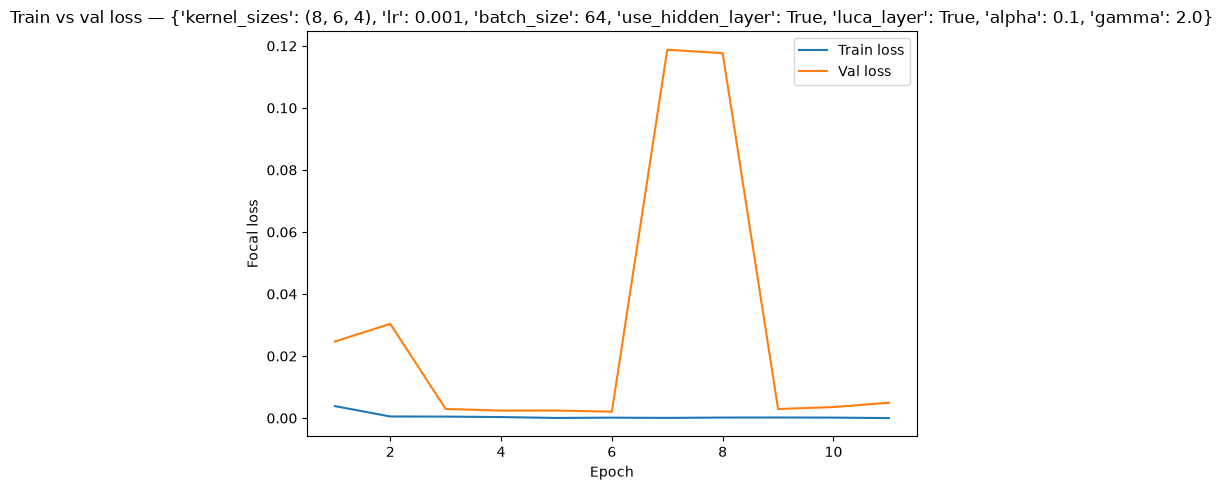

In [12]:
import matplotlib.pyplot as plt

# Train once on the original train/val split with the CV-winning config,
# purely to visualize the loss curves (separate from the CV/test pipeline).
best_config = cv_results[0]["config"]
split_result = run_one_config(
    best_config, X_train, y_train, X_val, y_val, device,
    verbose=True, config_id="single_split_plot"
)

history = split_result["history"]
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Focal loss")
plt.title(f"Train vs val loss — {best_config}")
plt.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

         neg      0.995     0.994     0.995      1555
         pos      0.500     0.529     0.514        17

    accuracy                          0.989      1572
   macro avg      0.747     0.762     0.754      1572
weighted avg      0.990     0.989     0.989      1572



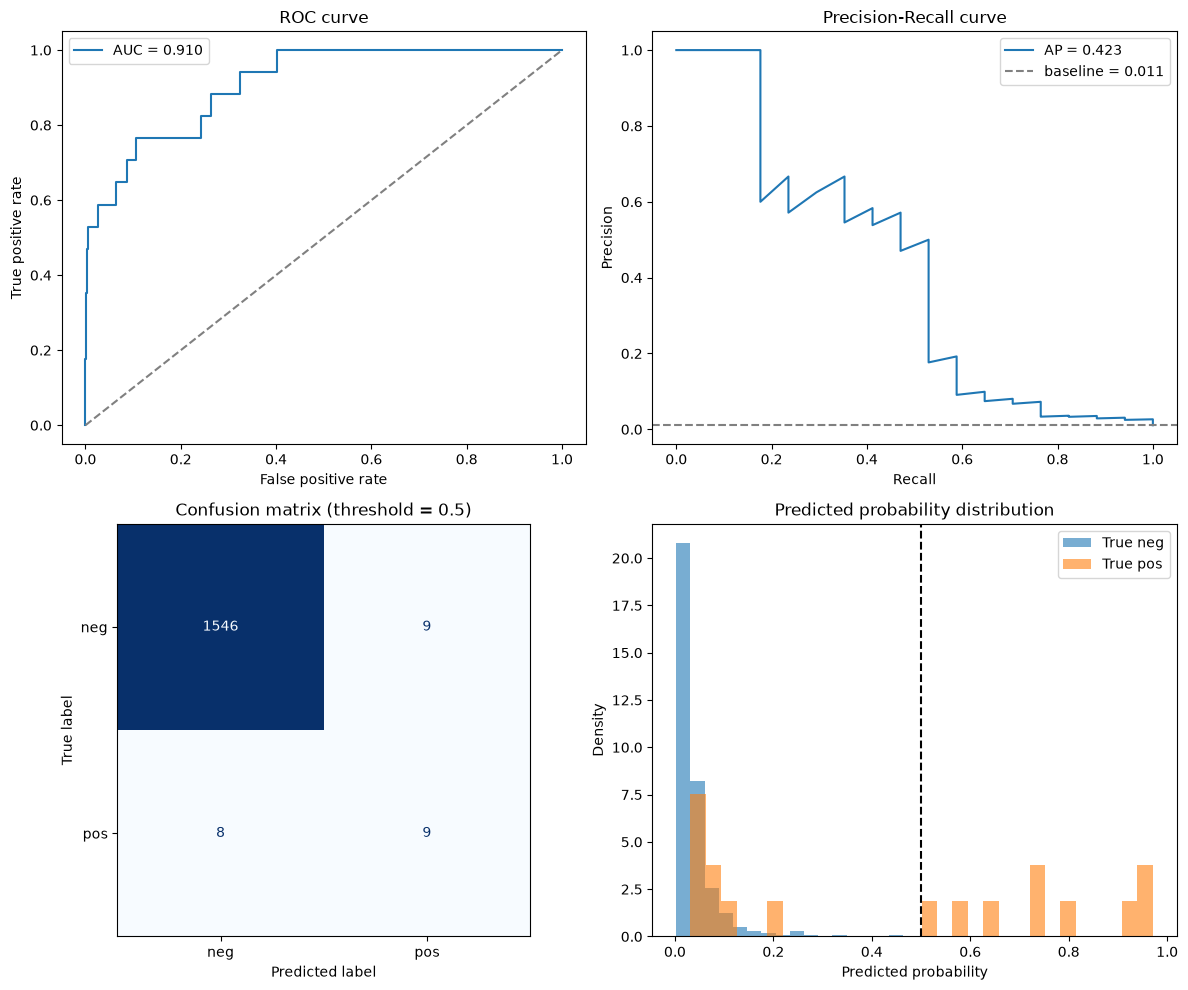

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

def get_predictions(model, X, y, device, batch_size=128):
    model.eval()
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size)
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb).squeeze(-1)).cpu()
            all_probs.append(probs)
            all_labels.append(yb)
    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()

# Rebuild the final architecture and load the refit weights from refit_and_test()
final_model = TranscriptCNN(
    kernel_sizes=best_config["kernel_sizes"],
    use_hidden_layer=best_config["use_hidden_layer"],
    luca_layer=best_config.get("luca_layer", False),
).to(device)
final_model.load_state_dict(final_result["state_dict"])

test_probs, test_labels = get_predictions(final_model, X_test, y_test, device)
test_preds = (test_probs > 0.5).astype(int)

print(classification_report(test_labels, test_preds, digits=3, target_names=["neg", "pos"]))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False positive rate")
axes[0, 0].set_ylabel("True positive rate")
axes[0, 0].set_title("ROC curve")
axes[0, 0].legend()

# Precision-recall curve -- the more informative one under class imbalance
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)
pos_rate = test_labels.mean()
axes[0, 1].plot(recall, precision, label=f"AP = {ap:.3f}")
axes[0, 1].axhline(pos_rate, ls="--", color="gray", label=f"baseline = {pos_rate:.3f}")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall curve")
axes[0, 1].legend()

# Confusion matrix at the default 0.5 threshold
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"]).plot(
    ax=axes[1, 0], colorbar=False, cmap="Blues"
)
axes[1, 0].set_title("Confusion matrix (threshold = 0.5)")

# Predicted-probability distribution by true class -- shows separability
# and whether the model is well-calibrated around the decision boundary
axes[1, 1].hist(test_probs[test_labels == 0], bins=30, alpha=0.6, density=True, label="True neg")
axes[1, 1].hist(test_probs[test_labels == 1], bins=30, alpha=0.6, density=True, label="True pos")
axes[1, 1].axvline(0.5, ls="--", color="k")
axes[1, 1].set_xlabel("Predicted probability")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Predicted probability distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Export the experiment outputs as a reusable PyTorch checkpoint.
experiment_results = {
    "selected_rbp": selected_rbp,
    "target_col": target_col,
    "max_len": MAX_LEN,
    "best_config": results[0]["config"],
    "best_val_auprc": results[0]["best_val_auprc"],
    "best_val_f1": results[0]["val_f1_at_best"],
    "best_state_dict": results[0]["state_dict"],
    "all_results": [
        {key: value for key, value in result.items() if key != "state_dict"}
        for result in results
    ],
    "split_indices": {
        "train": train_idx,
        "validation": val_idx,
        "test": test_idx,
    },
}

results_file = "rna_binding_experiment_results2.pt"

torch.save(experiment_results, results_file)
print(f"Exported to {results_file}")

Exported to rna_binding_experiment_results2.pt


In [27]:
import itertools
import copy
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import average_precision_score, f1_score


# ---- Reuse your existing pieces ----
class EarlyStopping:
    def __init__(self, patience=5, mode="max", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True
        improved = (
            score < self.best_score - self.min_delta
            if self.mode == "min"
            else score > self.best_score + self.min_delta
        )
        if improved:
            self.best_score = score
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device).float()
            logits = model(xb).squeeze(-1)
            total_loss += criterion(logits, yb).item() * xb.size(0)
            all_probs.append(torch.sigmoid(logits).cpu())
            all_labels.append(yb.cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return (
        total_loss / len(loader.dataset),
        average_precision_score(all_labels, all_probs),
        f1_score(all_labels, all_probs > 0.5),
    )


# ---- Parameterized model (kernel sizes now configurable) ----
class TranscriptCNN(nn.Module):
    def __init__(self, kernel_sizes=(8, 6, 4)):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Conv1d(5, 32, kernel_size=k1, padding='same')
        self.conv2 = nn.Conv1d(32, 64, kernel_size=k2, padding='same')
        self.conv3 = nn.Conv1d(64, 128, kernel_size=k3, padding='same')
        self.pool = nn.MaxPool1d(4)
        self.autopool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.autopool(torch.relu(self.conv3(x)))
        return self.classifier(x)


class RegularisedTranscriptCNN(nn.Module):
    # TODO: Add batchnorm, dropout and L2.
    def __init__(self, kernel_sizes=(8, 6, 4)):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Conv1d(5, 32, kernel_size=k1, padding='same')
        self.conv2 = nn.Conv1d(32, 64, kernel_size=k2, padding='same')
        self.conv3 = nn.Conv1d(64, 128, kernel_size=k3, padding='same')
        self.pool = nn.MaxPool1d(4)
        self.autopool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.autopool(torch.relu(self.conv3(x)))
        return self.classifier(x)

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) # prevents nans when probability 0
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

# ---- Grid definition ----
GRID = {
    "kernel_sizes": [(8, 6, 4)],  # (12, 8, 5), (15, 9, 5)],
    "pos_weight_mult": [0.5, 1.0, 2.0],   # multiplier on n_neg/n_pos
    "lr": [1e-3],
    "batch_size": [32, 64],
}

MAX_EPOCHS = 40           # keep short during search; do a longer final run on the winner
PATIENCE = 5


def make_loaders(X_train, y_train, X_val, y_val, batch_size):
    n_pos = y_train.sum().item()
    n_neg = len(y_train) - n_pos
    sample_weights = torch.where(y_train == 1, 1.0 / n_pos, 1.0 / n_neg)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

    # n_neg / n_pos is the base ratio for pos_weight in BCEWithLogitsLoss
    # Instead of using it directly, we multiply it by a hyperparameter (pos_weight_mult) to allow for tuning the effect of class imbalance.
    # Another option is to use the sqrt, so the pos_weight is not too extreme
    return train_loader, val_loader, n_neg / n_pos  # base ratio for pos_weight


def run_one_config(config, X_train, y_train, X_val, y_val, device):
    train_loader, val_loader, base_ratio = make_loaders(
        X_train, y_train, X_val, y_val, config["batch_size"]
    )
    pos_weight = torch.tensor([base_ratio * config["pos_weight_mult"]]).to(device)

    model = TranscriptCNN(kernel_sizes=config["kernel_sizes"]).to(device)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion = FocalLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    early_stopper = EarlyStopping(patience=PATIENCE, mode="max")

    best_state = None
    for epoch in range(MAX_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(1), yb)
            loss.backward()
            optimizer.step()

        _, val_auprc, val_f1 = evaluate(model, val_loader, criterion, device)
        if early_stopper.step(val_auprc):
            best_state = copy.deepcopy(model.state_dict())
            best_f1_at_best_auprc = val_f1
        if early_stopper.should_stop:
            break

    return {
        "config": config,
        "best_val_auprc": early_stopper.best_score,
        "val_f1_at_best": best_f1_at_best_auprc,
        "epochs_run": epoch + 1,
        "state_dict": best_state,
    }


def grid_search(X_train, y_train, X_val, y_val, device):
    keys = list(GRID.keys())
    combos = list(itertools.product(*GRID.values()))
    print(f"Running {len(combos)} configurations")

    results = []
    for i, values in enumerate(combos):
        config = dict(zip(keys, values))
        print(f"\n[{i+1}/{len(combos)}] {config}")
        result = run_one_config(config, X_train, y_train, X_val, y_val, device)
        print(f"  -> val_auprc={result['best_val_auprc']:.4f} "
              f"val_f1={result['val_f1_at_best']:.4f} epochs={result['epochs_run']}")
        results.append(result)

    results.sort(key=lambda r: r["best_val_auprc"], reverse=True)

    # Save best model + a log of everything tried (without state_dicts, those are large)
    torch.save(results[0]["state_dict"], "best_grid_search_model.pt")
    log = [{k: v for k, v in r.items() if k != "state_dict"} for r in results]
    with open("grid_search_results.json", "w") as f:
        json.dump(log, f, indent=2, default=str)

    print("\nBest config:", results[0]["config"])
    print("Best val AUPRC:", results[0]["best_val_auprc"])
    return results


# Usage:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = grid_search(X_train, y_train, X_val, y_val, device)

Running 6 configurations

[1/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.2957 val_f1=0.3000 epochs=8

[2/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.3357 val_f1=0.4516 epochs=18

[3/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.3077 val_f1=0.2857 epochs=7

[4/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.2805 val_f1=0.2857 epochs=19

[5/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.3685 val_f1=0.3415 epochs=9

[6/6] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.3695 val_f1=0.3390 epochs=9

Best config: {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.001, 'batch_size': 64}
Best val AUPRC: 0.3694506352467384


In [ ]:
Running 18 configurations

[1/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2833 val_f1=0.3182 epochs=15

[2/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.3556 val_f1=0.4103 epochs=7

[3/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.3296 val_f1=0.4615 epochs=12

[4/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2343 val_f1=0.2553 epochs=12

[5/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.1557 val_f1=0.2162 epochs=7

[6/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2410 val_f1=0.3590 epochs=11

[7/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2908 val_f1=0.1978 epochs=6

[8/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.3203 val_f1=0.3077 epochs=14

[9/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2639 val_f1=0.2174 epochs=7

[10/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.1701 val_f1=0.2424 epochs=7

[11/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2282 val_f1=0.3438 epochs=10

[12/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2376 val_f1=0.3188 epochs=9

[13/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.3926 val_f1=0.3529 epochs=17

[14/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.3026 val_f1=0.0830 epochs=6

[15/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}

In [ ]:
Running 18 configurations

[1/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2775 val_f1=0.3265 epochs=15

[2/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2038 val_f1=0.3000 epochs=8

[3/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2893 val_f1=0.2268 epochs=7

[4/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.1695 val_f1=0.2353 epochs=12

[5/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.3335 val_f1=0.3385 epochs=11

[6/18] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.1853 val_f1=0.0214 epochs=8

[7/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.1656 val_f1=0.1714 epochs=7

[8/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2490 val_f1=0.2800 epochs=15

[9/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2552 val_f1=0.2118 epochs=7

[10/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2569 val_f1=0.3600 epochs=13

[11/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2794 val_f1=0.0214 epochs=10

[12/18] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.1442 val_f1=0.1606 epochs=12

[13/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2571 val_f1=0.0913 epochs=6

[14/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 0.5, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2331 val_f1=0.2857 epochs=10

[15/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.2018 val_f1=0.3019 epochs=13

[16/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 1.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2497 val_f1=0.2785 epochs=8

[17/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
  -> val_auprc=0.3261 val_f1=0.2424 epochs=11

[18/18] {'kernel_sizes': (15, 9, 5), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 64}
  -> val_auprc=0.2128 val_f1=0.2400 epochs=10

Best config: {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.01, 'batch_size': 32}
Best val AUPRC: 0.3334532127495698

In [ ]:
Config	Kernel Sizes	Pos Weight Mult	Learning Rate	Batch Size	Val AUPRC	Val F1	Epochs
1/36	(8, 6, 4)	0.5	0.0001	32	0.3311	0.0214	8
2/36	(8, 6, 4)	0.5	0.0001	64	0.3313	0.0214	12
3/36	(8, 6, 4)	0.5	0.001	32	0.4244	0.3871	20
4/36	(8, 6, 4)	0.5	0.001	64	0.3184	0.0214	6
5/36	(8, 6, 4)	1.0	0.0001	32	0.3898	0.0214	7
6/36	(8, 6, 4)	1.0	0.0001	64	0.2505	0.0214	13
7/36	(8, 6, 4)	1.0	0.001	32	0.2778	0.0214	6
8/36	(8, 6, 4)	1.0	0.001	64	0.2657	0.0214	6
9/36	(8, 6, 4)	2.0	0.0001	32	0.2779	0.0214	11
10/36	(8, 6, 4)	2.0	0.0001	64	0.2591	0.0214	17
11/36	(8, 6, 4)	2.0	0.001	32	0.2488	0.0214	6
12/36	(8, 6, 4)	2.0	0.001	64	0.2224	0.1515	11
13/36	(12, 8, 5)	0.5	0.0001	32	0.2536	0.0214	8
14/36	(12, 8, 5)	0.5	0.0001	64	0.2595	0.0244	14
15/36	(12, 8, 5)	0.5	0.001	32	0.3134	0.4375	11
16/36	(12, 8, 5)	0.5	0.001	64	0.3913	0.2692	16
17/36	(12, 8, 5)	1.0	0.0001	32	0.2771	0.0214	9
18/36	(12, 8, 5)	1.0	0.0001	64	0.2710	0.0214	12
19/36	(12, 8, 5)	1.0	0.001	32	0.2785	0.2963	11
20/36	(12, 8, 5)	1.0	0.001	64	0.2610	0.3125	18
21/36	(12, 8, 5)	2.0	0.0001

Running 36 configurations

[1/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.0001, 'batch_size': 32}
  -> val_auprc=0.3311 val_f1=0.0214 epochs=8

[2/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.0001, 'batch_size': 64}
  -> val_auprc=0.3313 val_f1=0.0214 epochs=12

[3/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.4244 val_f1=0.3871 epochs=20

[4/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.3184 val_f1=0.0214 epochs=6

[5/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.0001, 'batch_size': 32}
  -> val_auprc=0.3898 val_f1=0.0214 epochs=7

[6/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.0001, 'batch_size': 64}
  -> val_auprc=0.2505 val_f1=0.0214 epochs=13

[7/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.2778 val_f1=0.0214 epochs=6

[8/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.2657 val_f1=0.0214 epochs=6

[9/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.0001, 'batch_size': 32}
  -> val_auprc=0.2779 val_f1=0.0214 epochs=11

[10/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.0001, 'batch_size': 64}
  -> val_auprc=0.2591 val_f1=0.0214 epochs=17

[11/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.2488 val_f1=0.0214 epochs=6

[12/36] {'kernel_sizes': (8, 6, 4), 'pos_weight_mult': 2.0, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.2224 val_f1=0.1515 epochs=11

[13/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.0001, 'batch_size': 32}
  -> val_auprc=0.2536 val_f1=0.0214 epochs=8

[14/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.0001, 'batch_size': 64}
  -> val_auprc=0.2595 val_f1=0.0244 epochs=14

[15/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.3134 val_f1=0.4375 epochs=11

[16/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 0.5, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.3913 val_f1=0.2692 epochs=16

[17/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.0001, 'batch_size': 32}
  -> val_auprc=0.2771 val_f1=0.0214 epochs=9

[18/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.0001, 'batch_size': 64}
  -> val_auprc=0.2710 val_f1=0.0214 epochs=12

[19/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 32}
  -> val_auprc=0.2785 val_f1=0.2963 epochs=11

[20/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 1.0, 'lr': 0.001, 'batch_size': 64}
  -> val_auprc=0.2610 val_f1=0.3125 epochs=18

[21/36] {'kernel_sizes': (12, 8, 5), 'pos_weight_mult': 2.0, 'lr': 0.0001, 'batch_size': 32}
---------------------------------------------------------------------------